# Insurance Cross-Sell — Simple Notebook

This notebook loads a CSV, preprocesses features, trains a small neural network,
and prints basic evaluation metrics. It's kept simple and runnable.

### Setup (one-time)
Install required packages:
```bash
pip install numpy pandas scikit-learn tensorflow joblib
```

In [8]:
import os
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
import joblib

# Reproducibility
seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

print('Libraries loaded — TensorFlow', tf.__version__)

Libraries loaded — TensorFlow 2.21.0


In [9]:
# Load data (expects data/train.csv)
data_path = 'data/train.csv'
if not os.path.exists(data_path):
    raise FileNotFoundError(f"{data_path} not found. Put your CSV in the data/ folder.")
df = pd.read_csv(data_path)
df = df.pipe(lambda d: d.rename(columns=lambda c: str(c).strip().lower().replace(' ', '_')))
print('Loaded', df.shape)
df.head()

Loaded (381109, 12)


,id,gender,age,driving_license,region_code,previously_insured,vehicle_age,vehicle_damage,annual_premium,policy_sales_channel,vintage,response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [10]:
# Detect target column and simple mapping
target_col = 'response'

# Drop identifier column if present
if 'id' in df.columns:
    df.drop(columns=['id'], inplace=True)

# Normalize target to 0/1
if df[target_col].dtype == object:
    df[target_col] = df[target_col].str.lower().map({'yes':1,'no':0})
    if df[target_col].isnull().any():
        df[target_col] = pd.to_numeric(df[target_col], errors='coerce')

# Recommended features for this dataset
standard = ['age','gender','driving_license','region_code','previously_insured','vehicle_age','vehicle_damage','annual_premium','policy_sales_channel','vintage']
# Pick features that exist in the dataframe
features = [c for c in standard if c in df.columns]
if not features:
    features = [c for c in df.select_dtypes(include=[np.number]).columns if c != target_col]
print('Using base features:', features)

# Simple mappings for common categorical columns
if 'gender' in df.columns and df['gender'].dtype == object:
    df['gender'] = df['gender'].str.lower().map({'male':1,'female':0})
if 'vehicle_damage' in df.columns and df['vehicle_damage'].dtype == object:
    df['vehicle_damage'] = df['vehicle_damage'].str.lower().map({'yes':1,'no':0})

# One-hot encode remaining object columns (except target)
cat_cols = [c for c in df.columns if df[c].dtype == 'object' and c != target_col]
if cat_cols:
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Expand feature list to include any dummy columns produced
expanded_features = []
for f in features:
    if f in df.columns:
        expanded_features.append(f)
    else:
        matched = [c for c in df.columns if c.startswith(f + '_')]
        expanded_features.extend(matched)

if expanded_features and set(expanded_features).issubset(df.columns):
    X = df[expanded_features].copy()
else:
    # Fallback: use all columns except the target
    X = df.drop(columns=[target_col]).copy()
    expanded_features = list(X.columns)

y = df[target_col].astype(int)
print('Using features (final):', expanded_features)
print('X shape:', X.shape, 'y shape:', y.shape)

Using base features: ['age', 'gender', 'driving_license', 'region_code', 'previously_insured', 'vehicle_age', 'vehicle_damage', 'annual_premium', 'policy_sales_channel', 'vintage']
Using features (final): ['age', 'gender', 'driving_license', 'region_code', 'previously_insured', 'vehicle_age_< 1 Year', 'vehicle_age_> 2 Years', 'vehicle_damage', 'annual_premium', 'policy_sales_channel', 'vintage']
X shape: (381109, 11) y shape: (381109,)


In [11]:
# Split and scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Train shape: (304887, 11) Test shape: (76222, 11)


In [12]:
# Small MLP
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_split=0.1, epochs=100, batch_size=32, callbacks=[es], verbose=2)

c:\Users\SubudhiK\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
8575/8575 - 16s - 2ms/step - accuracy: 0.8774 - loss: 0.2724 - val_accuracy: 0.8767 - val_loss: 0.2703
Epoch 2/100
8575/8575 - 15s - 2ms/step - accuracy: 0.8775 - loss: 0.2693 - val_accuracy: 0.8768 - val_loss: 0.2696
Epoch 3/100
8575/8575 - 15s - 2ms/step - accuracy: 0.8775 - loss: 0.2688 - val_accuracy: 0.8765 - val_loss: 0.2694
Epoch 4/100
8575/8575 - 15s - 2ms/step - accuracy: 0.8775 - loss: 0.2685 - val_accuracy: 0.8767 - val_loss: 0.2694
Epoch 5/100
8575/8575 - 19s - 2ms/step - accuracy: 0.8775 - loss: 0.2683 - val_accuracy: 0.8768 - val_loss: 0.2692
Epoch 6/100
8575/8575 - 17s - 2ms/step - accuracy: 0.8775 - loss: 0.2681 - val_accuracy: 0.8769 - val_loss: 0.2691
Epoch 7/100
8575/8575 - 18s - 2ms/step - accuracy: 0.8775 - loss: 0.2680 - val_accuracy: 0.8768 - val_loss: 0.2690
Epoch 8/100
8575/8575 - 29s - 3ms/step - accuracy: 0.8775 - loss: 0.2679 - val_accuracy: 0.8769 - val_loss: 0.2690
Epoch 9/100
8575/8575 - 18s - 2ms/step - accuracy: 0.8775 - loss: 0.2678 - val_a

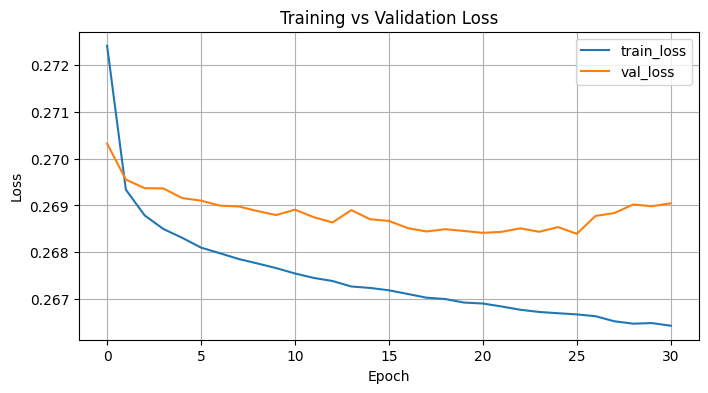

In [13]:
# Plot training vs validation loss per epoch
import matplotlib.pyplot as plt

loss = history.history.get('loss', [])
val_loss = history.history.get('val_loss', [])

plt.figure(figsize=(8,4))
plt.plot(loss, label='train_loss')
plt.plot(val_loss, label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Evaluate and save
y_prob = model.predict(X_test).ravel()
y_pred = (y_prob >= 0.5).astype(int)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred, zero_division=0))
print('Recall:', recall_score(y_test, y_pred, zero_division=0))
print('F1-score:', f1_score(y_test, y_pred, zero_division=0))
print('Classification report:', classification_report(y_test, y_pred, zero_division=0))
print('Confusion matrix:', confusion_matrix(y_test, y_pred))

model.save('insurance_model.h5')
joblib.dump(scaler, 'scaler.joblib')
print('Saved model -> insurance_model.h5 and scaler -> scaler.joblib')

2382/2382 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step
Accuracy: 0.8767285035816431
Precision: 0.4224137931034483
Recall: 0.01573538856775851
F1-score: 0.030340557275541795


Classification report:               precision    recall  f1-score   support

           0       0.88      1.00      0.93     66880
           1       0.42      0.02      0.03      9342

    accuracy                           0.88     76222
   macro avg       0.65      0.51      0.48     76222
weighted avg       0.82      0.88      0.82     76222

Confusion matrix: [[66679   201]
 [ 9195   147]]
Saved model -> insurance_model.h5 and scaler -> scaler.joblib
